# project04 - Compound multi-protocol strategy: Moonwell + Arcadia ETH/BTC LPs

A real-world leveraged-LP strategy stacked across two protocols:

1. **Outer leg (Moonwell / Aave)** - deposit USDC, borrow ETH and BTC.
2. **Inner leg (Arcadia Finance)** - two leveraged ETH/BTC concentrated-liquidity
   positions on the same tick range, one funded with ETH debt and one with
   BTC debt.

The strategy is **delta-balanced by construction**: position 1 carries an ETH
short via Arcadia debt, position 2 carries a BTC short via Arcadia debt. The
outer Moonwell loan adds another ETH+BTC short layered on top of the USDC
deposit. Net exposure to ETH and BTC tends to cancel inside the LP range and
diverge as the pool price drifts outside.

### Parameters (as supplied)

| | |
|---|---|
| Initial capital | **4 000 USDC** |
| Moonwell USDC supply APR | 5 % |
| Moonwell ETH borrow APR | 3 % (borrow $1 000 worth of ETH) |
| Moonwell BTC borrow APR | 1 % (borrow $1 000 worth of BTC) |
| Pool | ETH/BTC, fee tier 0.30 % |
| Pool price (now) | 0.02802 BTC per ETH |
| Range | [0.02740, 0.02880] |
| Quoted LP APY (fees, in-range) | 70 % |
| Position 1 leverage | 4x, debt token = **ETH** (Arcadia ETH borrow 6 %) |
| Position 2 leverage | 4x, debt token = **BTC** (Arcadia BTC borrow 2 %) |

### Price-anchor convention

The user-supplied numbers (`ETH = $2300`, `BTC = $79 000`, `pool = 0.02802`)
are not perfectly self-consistent because `$2300 / $79 000 = 0.02911` differs
from the stated pool price of `0.02802`. We anchor BTC at $79 000 and derive
the t=0 ETH USD price from the pool (so the $2300 figure is treated as the
ETH price at the time the **outer** borrow was sized, slightly earlier):

```
ETH_USD(t=0) = pool · BTC_USD = 0.02802 · 79 000 = $2 213.58
```

This keeps every dollar value self-consistent and makes the t=0 portfolio
equity exactly $4 000.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from lp_analysis import (
    AssetPair, PriceRange, PoolConfig, LendingPolicy, StrategyConfig,
    ScenarioPath, simulate,
    OuterLending, simulate_outer, lp_fees_path, in_range_mask,
    CompoundPortfolio,
    compute_pnl, compute_exposure, impermanent_loss,
    liquidation_price_bounds, margin_path, value_at_risk, expected_shortfall,
    plot_value_breakdown, plot_margin, plot_exposure, plot_composition,
    dashboard, to_frame,
)

plt.rcParams['figure.dpi'] = 110
np.set_printoptions(suppress=True, precision=6)

## 1. Strategy parameters

All numerical inputs are gathered in one block so the analysis can be replayed
on a different protocol or market quickly.

In [2]:
# --- USD oracle (anchor: BTC) --------------------------------------------- #
ETH_USD_BORROW = 2_300.0           # price at which the outer ETH borrow was sized
BTC_USD        = 79_000.0          # constant USD anchor for BTC
POOL_INIT      = 0.02802           # ETH/BTC pool price at t=0 (BTC per ETH)
ETH_USD_T0     = POOL_INIT * BTC_USD   # = 2213.58 -- derived for consistency

# --- LP range and fee APY ------------------------------------------------- #
RANGE_LOWER = 0.02740
RANGE_UPPER = 0.02880
LP_APY_PCT  = 70.0                 # quoted by Arcadia for this range

# --- Moonwell outer leg --------------------------------------------------- #
USDC_AMOUNT       = 4_000.0
USDC_SUPPLY_APR   = 5.0
ETH_BORROW_APR    = 3.0
BTC_BORROW_APR    = 1.0
USDC_CF           = 0.85
USDC_LF           = 0.90

OUTER_ETH_TOKENS = 1_000.0 / ETH_USD_BORROW    # 0.43478 ETH
OUTER_BTC_TOKENS = 1_000.0 / BTC_USD           # 0.012658 BTC

# --- Arcadia inner leg ---------------------------------------------------- #
ARCADIA_ETH_BORROW_APR = 6.0
ARCADIA_BTC_BORROW_APR = 2.0
ARCADIA_ETH_CF, ARCADIA_ETH_LF = 0.80, 0.85
ARCADIA_BTC_CF, ARCADIA_BTC_LF = 0.85, 0.90
LP_PROTOCOL_FACTOR = 0.95

# --- Strategy horizon ----------------------------------------------------- #
HORIZON_DAYS = 365.0

## 2. Build the outer Moonwell leg

`OuterLending` carries the collateral (USDC) and a dict of debt tokens, each
with its own borrow APR. Token quantities are fixed at borrow time; their USD
value moves with the oracle price paths supplied at simulation time.

In [3]:
outer_cfg = OuterLending(
    name="Moonwell USDC -> ETH + BTC",
    collateral_symbol="USDC",
    collateral_amount=USDC_AMOUNT,
    supply_apr_pct=USDC_SUPPLY_APR,
    debt_tokens={"ETH": OUTER_ETH_TOKENS, "BTC": OUTER_BTC_TOKENS},
    borrow_apr_pct={"ETH": ETH_BORROW_APR, "BTC": BTC_BORROW_APR},
    collateral_factor=USDC_CF,
    liquidation_factor=USDC_LF,
    protocol_name="Moonwell",
)
print(outer_cfg)

OuterLending(name='Moonwell USDC -> ETH + BTC', collateral_symbol='USDC', collateral_amount=4000.0, supply_apr_pct=5.0, debt_tokens={'ETH': 0.43478260869565216, 'BTC': 0.012658227848101266}, borrow_apr_pct={'ETH': 3.0, 'BTC': 1.0}, collateral_factor=0.85, liquidation_factor=0.9, protocol_name='Moonwell')


## 3. Build the two Arcadia LP positions

Each position uses the **same pool**, the **same range**, and **the same 4x
leverage**, but differs in the debt token (and hence the Arcadia borrow APR
and the natural delta orientation).

Equity sizing is taken directly from the user-supplied dollar amounts after
anchoring at BTC = $79 000 and pool = 0.02802. The two positions therefore
carry slightly different equity in BTC numeraire (0.012182 BTC vs 0.012658 BTC)
because the user's "$1 000 of ETH" sources tokens at the implied ETH = $2 213.58
while the "$1 000 of BTC" is exactly 0.012658 BTC at the anchor.

In [4]:
arcadia_policy = LendingPolicy(
    collateral_factors={"ETH": ARCADIA_ETH_CF, "BTC": ARCADIA_BTC_CF},
    liquidation_factors={"ETH": ARCADIA_ETH_LF, "BTC": ARCADIA_BTC_LF},
    borrow_apr_by_symbol={
        "ETH": ARCADIA_ETH_BORROW_APR,
        "BTC": ARCADIA_BTC_BORROW_APR,
    },
    lp_protocol_factor=LP_PROTOCOL_FACTOR,
)

pool = PoolConfig(
    pair=AssetPair("ETH", "BTC"),
    price_initial=POOL_INIT,
    price_range=PriceRange(RANGE_LOWER, RANGE_UPPER),
    fee_tier_pct=0.30,
)

# Equity (in BTC numeraire) for each position
cap1_btc = OUTER_ETH_TOKENS * POOL_INIT        # 0.012182 BTC ~ $962.42
cap2_btc = OUTER_BTC_TOKENS                    # 0.012658 BTC ~ $1000.00

pos1 = StrategyConfig(
    name="Arcadia ETH/BTC 4x (ETH debt)",
    pool=pool, lending=arcadia_policy,
    capital_asset1=cap1_btc, leverage=4.0, debt_symbol="ETH",
)
pos2 = StrategyConfig(
    name="Arcadia ETH/BTC 4x (BTC debt)",
    pool=pool, lending=arcadia_policy,
    capital_asset1=cap2_btc, leverage=4.0, debt_symbol="BTC",
)

print(pos1, end="\n\n")
print(pos2)

StrategyConfig(name='Arcadia ETH/BTC 4x (ETH debt)', pool=PoolConfig(pair=AssetPair(asset0='ETH', asset1='BTC'), price_initial=0.02802, price_range=PriceRange(lower=0.0274, upper=0.0288), fee_tier_pct=0.3), lending=LendingPolicy(collateral_factors={'ETH': 0.8, 'BTC': 0.85}, liquidation_factors={'ETH': 0.85, 'BTC': 0.9}, borrow_apr_by_symbol={'ETH': 6.0, 'BTC': 2.0}, lp_protocol_factor=0.95, minimum_margin_usd=0.0), capital_asset1=0.012182608695652174, leverage=4.0, debt_symbol='ETH')

StrategyConfig(name='Arcadia ETH/BTC 4x (BTC debt)', pool=PoolConfig(pair=AssetPair(asset0='ETH', asset1='BTC'), price_initial=0.02802, price_range=PriceRange(lower=0.0274, upper=0.0288), fee_tier_pct=0.3), lending=LendingPolicy(collateral_factors={'ETH': 0.8, 'BTC': 0.85}, liquidation_factors={'ETH': 0.85, 'BTC': 0.9}, borrow_apr_by_symbol={'ETH': 6.0, 'BTC': 2.0}, lp_protocol_factor=0.95, minimum_margin_usd=0.0), capital_asset1=0.012658227848101266, leverage=4.0, debt_symbol='BTC')


## 4. t=0 snapshot — verify the books balance

Run a single-point scenario at the initial state and confirm the user's
$4 000 capital reconciles exactly.

In [5]:
flat_prices = np.array([POOL_INIT])
flat_t      = np.array([0.0])
flat_usd    = {
    "ETH":  np.array([ETH_USD_T0]),
    "BTC":  np.array([BTC_USD]),
    "USDC": np.array([1.0]),
}
sc0 = ScenarioPath(price_path=flat_prices, t_days=flat_t, usd_prices=flat_usd)

r1_0    = simulate(pos1, sc0)
r2_0    = simulate(pos2, sc0)
outer_0 = simulate_outer(outer_cfg, t_days=flat_t, usd_prices=flat_usd)

fees0 = [lp_fees_path(np.zeros_like(flat_t), LP_APY_PCT, flat_t) for _ in range(2)]
port0 = CompoundPortfolio(
    outer=outer_0, lp_results=[r1_0, r2_0],
    lp_fee_paths=fees0,
    initial_user_capital_usd=USDC_AMOUNT,
)

def summarise(label, value):
    return f"  {label:<24s}: $ {value:>10,.2f}"

print("--- Outer Moonwell leg (t=0) ---")
print(summarise("USDC collateral", outer_0.collateral_value_usd[0]))
print(summarise("ETH debt", outer_0.debt_value_usd_by_symbol['ETH'][0]))
print(summarise("BTC debt", outer_0.debt_value_usd_by_symbol['BTC'][0]))
print(summarise("Outer equity", outer_0.equity_usd[0]))
print(f"  Health factor          : {outer_0.health_factor[0]:>10.3f}")
print()
print("--- Arcadia LP positions (t=0) ---")
for tag, r in [("LP1 (ETH debt)", r1_0), ("LP2 (BTC debt)", r2_0)]:
    pos_usd  = r.amount0[0] * ETH_USD_T0 + r.amount1[0] * BTC_USD
    debt_usd = (r.debt_amount[0] * ETH_USD_T0
                if r.initial.debt_token == "ETH"
                else r.debt_amount[0] * BTC_USD)
    print(f"  {tag}")
    print(f"    LP holds       : {r.amount0[0]:.6f} ETH  +  {r.amount1[0]:.6f} BTC")
    print(f"    Position USD   : $ {pos_usd:>10,.2f}")
    print(f"    Debt USD       : $ {debt_usd:>10,.2f}")
    print(f"    Equity USD     : $ {pos_usd - debt_usd:>10,.2f}")
print()
print("--- Combined portfolio (t=0) ---")
print(summarise("Portfolio equity", port0.portfolio_equity_usd()[0]))
print(summarise("PnL vs $4 000",    port0.portfolio_pnl_usd()[0]))
print(f"  PnL %                   : {port0.portfolio_pnl_pct()[0]:>10.4f}%")

--- Outer Moonwell leg (t=0) ---
  USDC collateral         : $   4,000.00
  ETH debt                : $     962.43
  BTC debt                : $   1,000.00
  Outer equity            : $   2,037.57
  Health factor          :      1.834

--- Arcadia LP positions (t=0) ---
  LP1 (ETH debt)
    LP holds       : 0.957688 ETH  +  0.021896 BTC
    Position USD   : $   3,849.70
    Debt USD       : $   2,887.28
    Equity USD     : $     962.43
  LP2 (BTC debt)
    LP holds       : 0.995077 ETH  +  0.022751 BTC
    Position USD   : $   4,000.00
    Debt USD       : $   3,000.00
    Equity USD     : $   1,000.00

--- Combined portfolio (t=0) ---
  Portfolio equity        : $   4,000.00
  PnL vs $4 000           : $       0.00
  PnL %                   :     0.0000%


## 5. 1-D price-sweep — pool price varies, BTC USD held flat

The simplest stress sweep: vary the pool price across a window wider than the
LP range with **BTC USD held flat at $79 000** so ETH USD moves
proportionally. Time is held at t=0 so interest and LP fees don't fold in -
this isolates the pure mark-to-market profile of the position structure.

In [6]:
def build_sweep_scenario(n_points: int = 401,
                         price_min: float = 0.025,
                         price_max: float = 0.032,
                         t_days: float = 0.0) -> ScenarioPath:
    prices = np.linspace(price_min, price_max, n_points)
    days   = np.full(n_points, float(t_days))
    btc_usd_path = np.full(n_points, BTC_USD)
    eth_usd_path = prices * btc_usd_path        # consistent with pool
    usdc_usd_path = np.ones(n_points)
    return ScenarioPath(price_path=prices, t_days=days,
                        usd_prices={"ETH": eth_usd_path,
                                    "BTC": btc_usd_path,
                                    "USDC": usdc_usd_path})

sc_sweep = build_sweep_scenario()

r1 = simulate(pos1, sc_sweep)
r2 = simulate(pos2, sc_sweep)
outer_path = simulate_outer(outer_cfg, sc_sweep.t_days, sc_sweep.usd_prices)

# Fees stay at 0 because t_days is 0 here; risk profile is the spot mark-to-market.
fees_sweep = [lp_fees_path(np.zeros_like(sc_sweep.t_days), LP_APY_PCT, sc_sweep.t_days),
              lp_fees_path(np.zeros_like(sc_sweep.t_days), LP_APY_PCT, sc_sweep.t_days)]

port_sweep = CompoundPortfolio(
    outer=outer_path, lp_results=[r1, r2],
    lp_fee_paths=fees_sweep,
    initial_user_capital_usd=USDC_AMOUNT,
)
print(f"Swept {sc_sweep.n_steps} pool prices from {sc_sweep.price_path.min():.5f} to {sc_sweep.price_path.max():.5f}")

Swept 401 pool prices from 0.02500 to 0.03200


### 5a. PnL profile in USD

The combined portfolio's USD equity vs. pool price tells you, at a glance:

* Where the strategy is symmetric (peak typically near the LP range centre).
* Where the LP runs out of range and the position becomes 100 % of the
  "wrong" asset.
* How the two debt-token choices in positions 1 and 2 partly cancel.

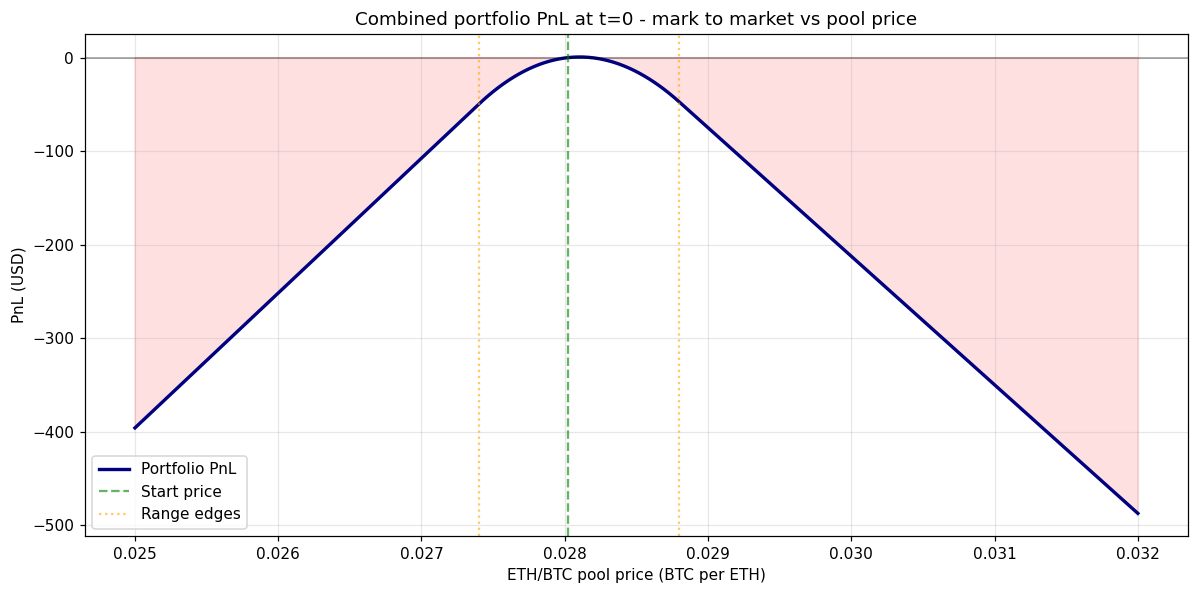

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.5))
p = sc_sweep.price_path
pnl_total = port_sweep.portfolio_pnl_usd()
ax.plot(p, pnl_total, linewidth=2.2, color='navy', label='Portfolio PnL')
ax.axhline(0, color='black', alpha=0.4, linewidth=1)
ax.fill_between(p, 0, pnl_total, where=pnl_total >= 0, color='green', alpha=0.12)
ax.fill_between(p, 0, pnl_total, where=pnl_total <  0, color='red',   alpha=0.12)
ax.axvline(POOL_INIT,   color='green',  linestyle='--', alpha=0.6, label='Start price')
ax.axvline(RANGE_LOWER, color='orange', linestyle=':',  alpha=0.6, label='Range edges')
ax.axvline(RANGE_UPPER, color='orange', linestyle=':',  alpha=0.6)
ax.set_xlabel('ETH/BTC pool price (BTC per ETH)')
ax.set_ylabel('PnL (USD)')
ax.set_title('Combined portfolio PnL at t=0 - mark to market vs pool price')
ax.grid(alpha=0.3); ax.legend(loc='best')
plt.tight_layout(); plt.show()

### 5b. Composition: outer leg + each LP + cumulative fees

Stacking the per-leg USD equity highlights which leg drives the loss and
which leg counterbalances on either side of the range.

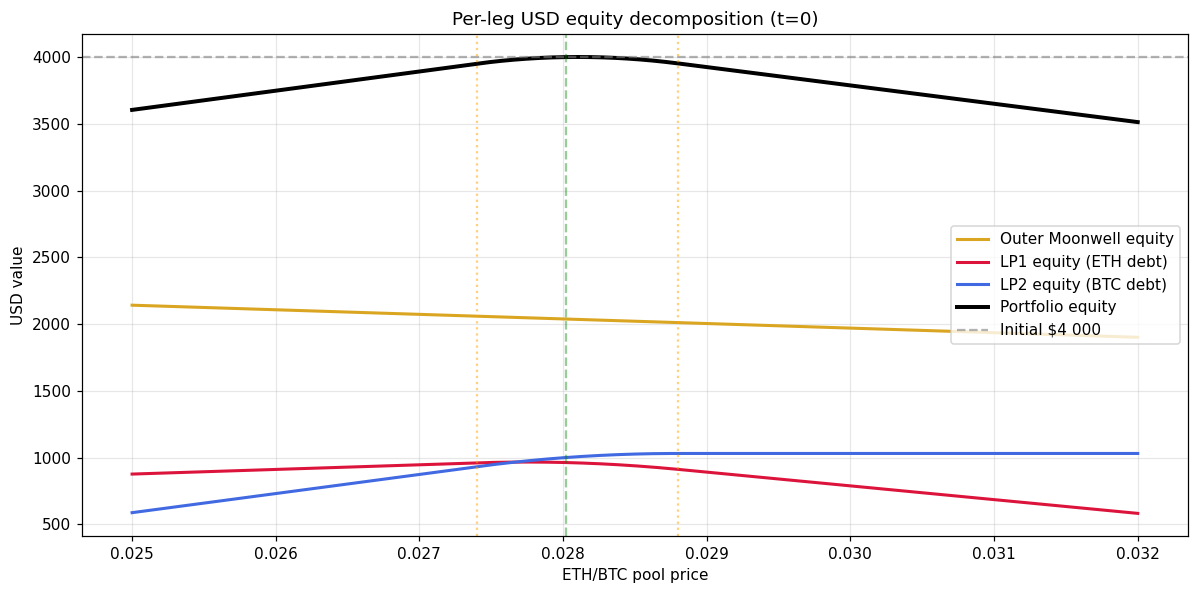

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5))
p = sc_sweep.price_path
outer_eq = port_sweep.outer.equity_usd
lp1_eq   = port_sweep.lp_equity_value_usd(0)
lp2_eq   = port_sweep.lp_equity_value_usd(1)

ax.plot(p, outer_eq, color='goldenrod', linewidth=2.0, label='Outer Moonwell equity')
ax.plot(p, lp1_eq,   color='crimson',   linewidth=2.0, label='LP1 equity (ETH debt)')
ax.plot(p, lp2_eq,   color='royalblue', linewidth=2.0, label='LP2 equity (BTC debt)')
ax.plot(p, outer_eq + lp1_eq + lp2_eq, color='black', linewidth=2.6, label='Portfolio equity')
ax.axhline(USDC_AMOUNT, color='grey', linestyle='--', alpha=0.6, label='Initial $4 000')
ax.axvline(POOL_INIT,   color='green',  linestyle='--', alpha=0.4)
ax.axvline(RANGE_LOWER, color='orange', linestyle=':',  alpha=0.5)
ax.axvline(RANGE_UPPER, color='orange', linestyle=':',  alpha=0.5)
ax.set_xlabel('ETH/BTC pool price'); ax.set_ylabel('USD value')
ax.set_title('Per-leg USD equity decomposition (t=0)')
ax.grid(alpha=0.3); ax.legend(loc='best')
plt.tight_layout(); plt.show()

### 5c. Per-position Arcadia dashboard

The four-panel dashboards reuse the codebase's `dashboard()` helper to inspect
each LP individually (value/debt/equity, margin, exposure, PnL).

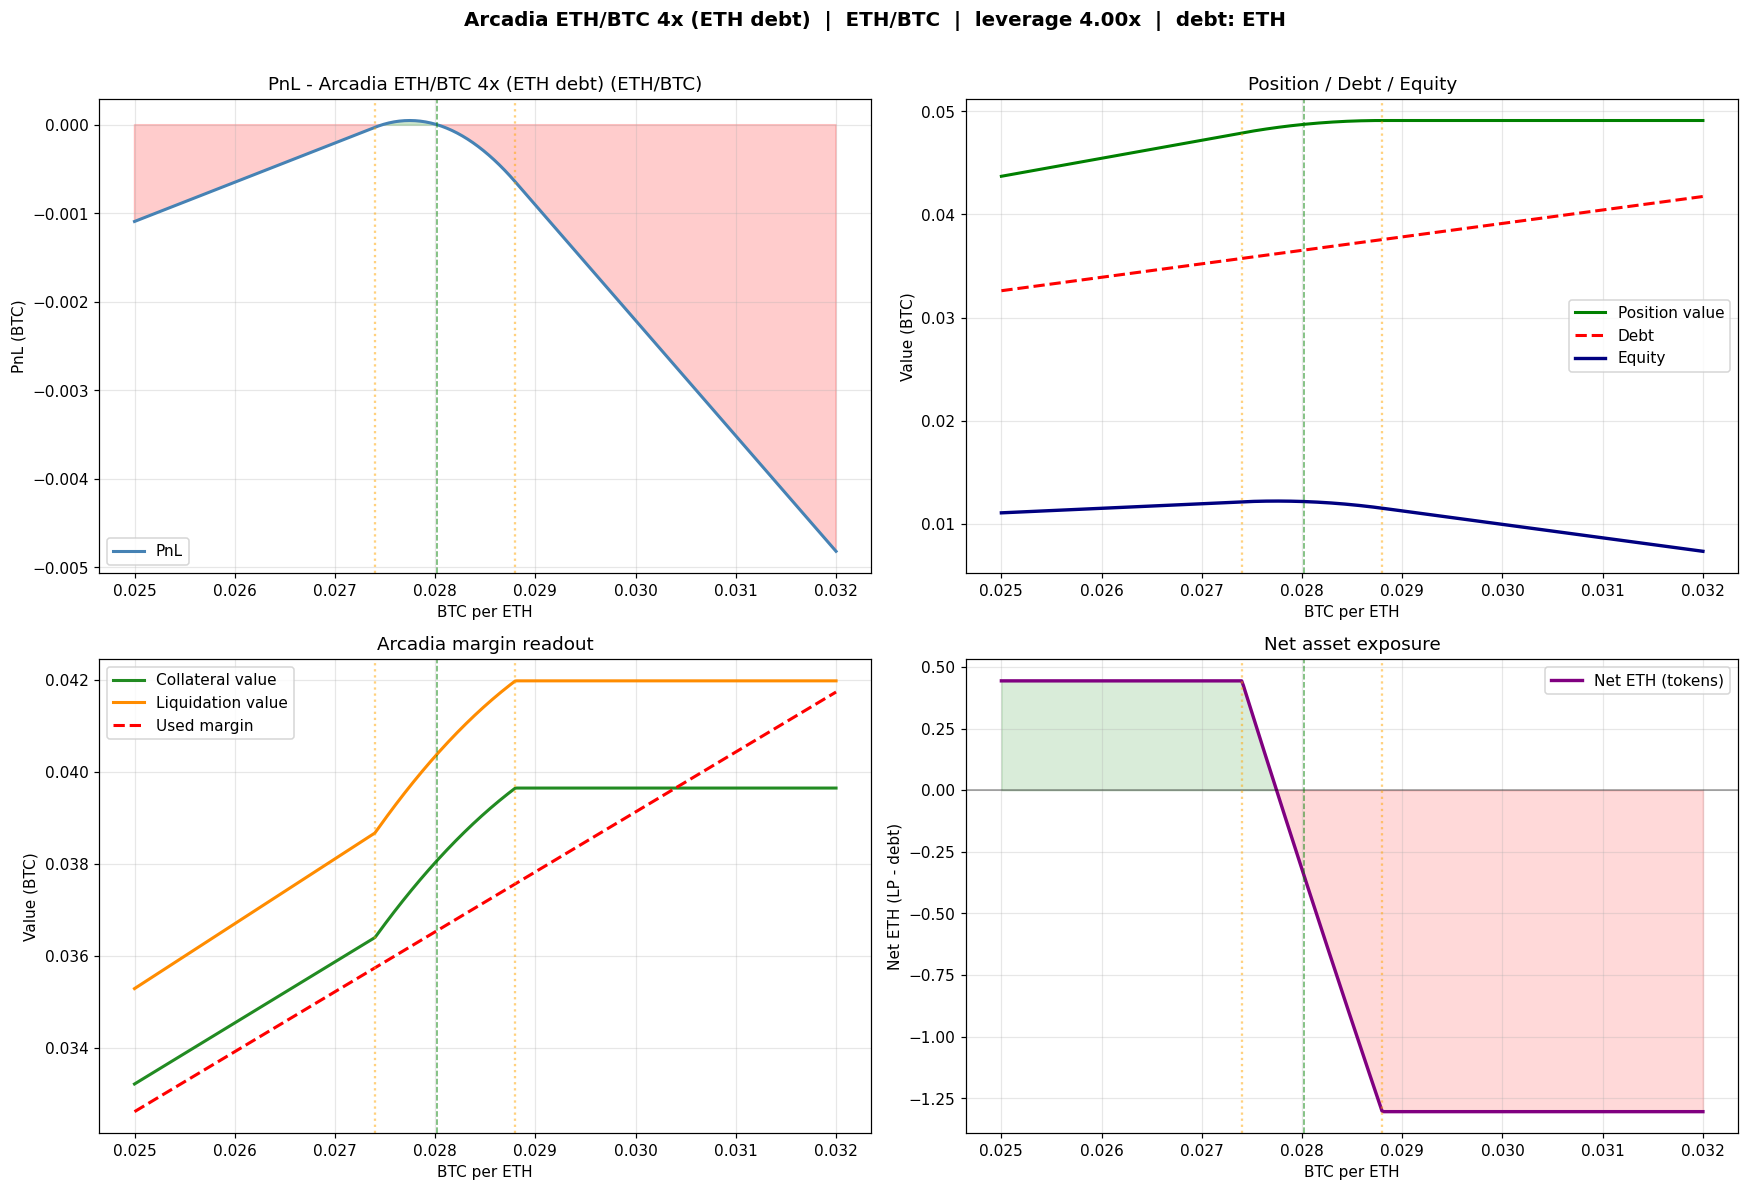

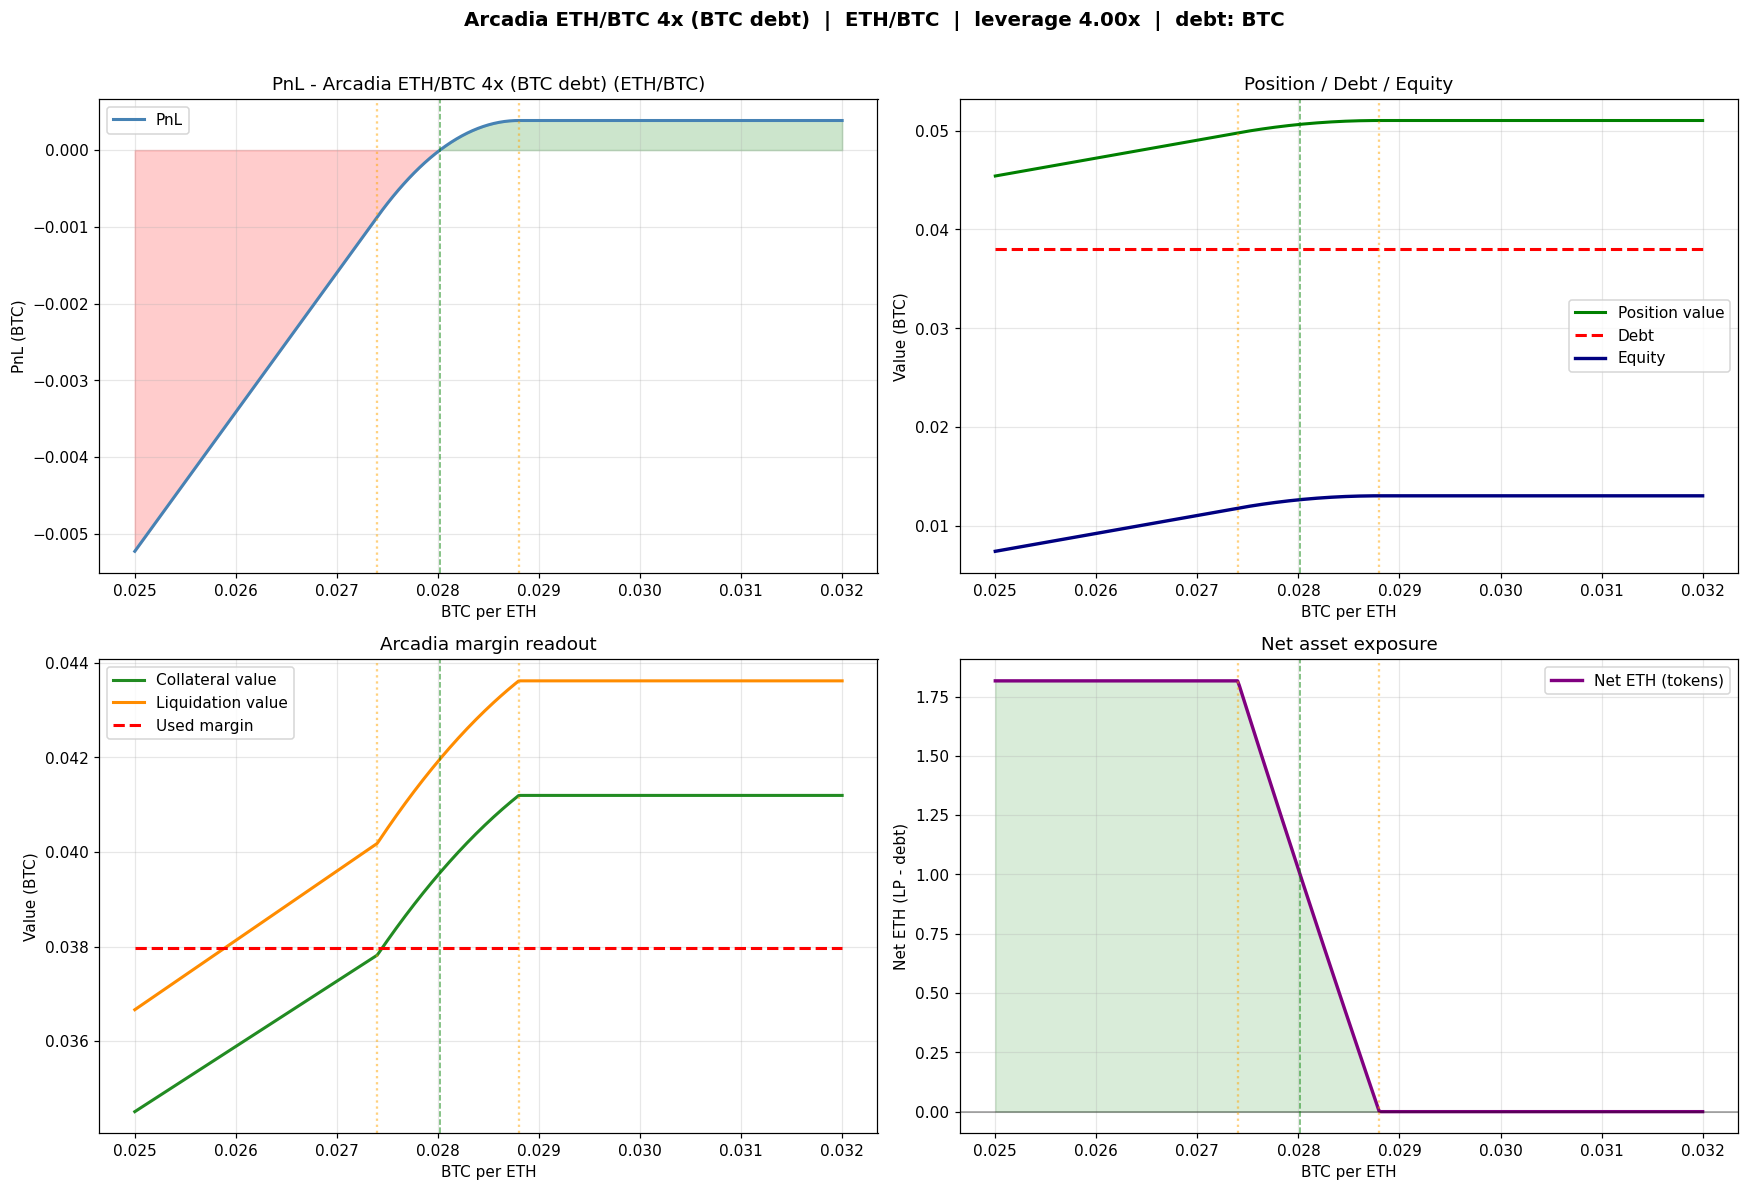

In [9]:
fig1 = dashboard(r1)
plt.show()
fig2 = dashboard(r2)
plt.show()

## 6. 1-year time projection - random-walk price path

A `simulate`-grade scenario with a daily-step price walk lets the model fold
in continuous interest accrual and LP fees over time.

* Pool price: geometric Brownian motion (mu=0, sigma=0.6 / sqrt(365)) - low-vol
  ETH/BTC ratio, drift 0.
* BTC USD: flat at $79 000.
* ETH USD: `pool_price · BTC_USD` so the cross stays consistent.
* LP fees accrue at 70 % APY only while the pool sits inside the range.

In [10]:
def gbm_path(n: int, p0: float, sigma_ann: float, rng: np.random.Generator) -> np.ndarray:
    dt = 1.0 / 365.0
    z = rng.standard_normal(n - 1)
    logret = (-0.5 * sigma_ann**2) * dt + sigma_ann * np.sqrt(dt) * z
    p = np.empty(n); p[0] = p0
    p[1:] = p0 * np.exp(np.cumsum(logret))
    return p

rng    = np.random.default_rng(42)
n_days = int(HORIZON_DAYS) + 1
t_days = np.arange(n_days, dtype=float)
prices = gbm_path(n_days, POOL_INIT, sigma_ann=0.35, rng=rng)
btc    = np.full(n_days, BTC_USD)
eth    = prices * btc
usdc   = np.ones(n_days)
sc_time = ScenarioPath(price_path=prices, t_days=t_days,
                       usd_prices={"ETH": eth, "BTC": btc, "USDC": usdc})

r1_t    = simulate(pos1, sc_time)
r2_t    = simulate(pos2, sc_time)
outer_t = simulate_outer(outer_cfg, sc_time.t_days, sc_time.usd_prices)

# LP fees accrue only while in range, applied to the live USD notional
in_rng = in_range_mask(sc_time.price_path, RANGE_LOWER, RANGE_UPPER)
not1 = r1_t.amount0 * sc_time.usd_prices['ETH'] + r1_t.amount1 * sc_time.usd_prices['BTC']
not2 = r2_t.amount0 * sc_time.usd_prices['ETH'] + r2_t.amount1 * sc_time.usd_prices['BTC']
fees1 = lp_fees_path(not1, LP_APY_PCT, sc_time.t_days, in_range=in_rng)
fees2 = lp_fees_path(not2, LP_APY_PCT, sc_time.t_days, in_range=in_rng)

port_t = CompoundPortfolio(
    outer=outer_t, lp_results=[r1_t, r2_t],
    lp_fee_paths=[fees1, fees2],
    initial_user_capital_usd=USDC_AMOUNT,
)

frac_in_range = float(in_rng.mean())
print(f"Time in range: {frac_in_range*100:.1f}%  (over {n_days} daily steps)")
print(f"Final pool price: {prices[-1]:.5f}")
print(f"Final portfolio equity: $ {port_t.portfolio_equity_usd()[-1]:>10,.2f}")
print(f"Final PnL: $ {port_t.portfolio_pnl_usd()[-1]:>10,.2f}  ({port_t.portfolio_pnl_pct()[-1]:+.2f}%)")

Time in range: 13.4%  (over 366 daily steps)
Final pool price: 0.02482
Final portfolio equity: $   4,250.46
Final PnL: $     250.46  (+6.26%)


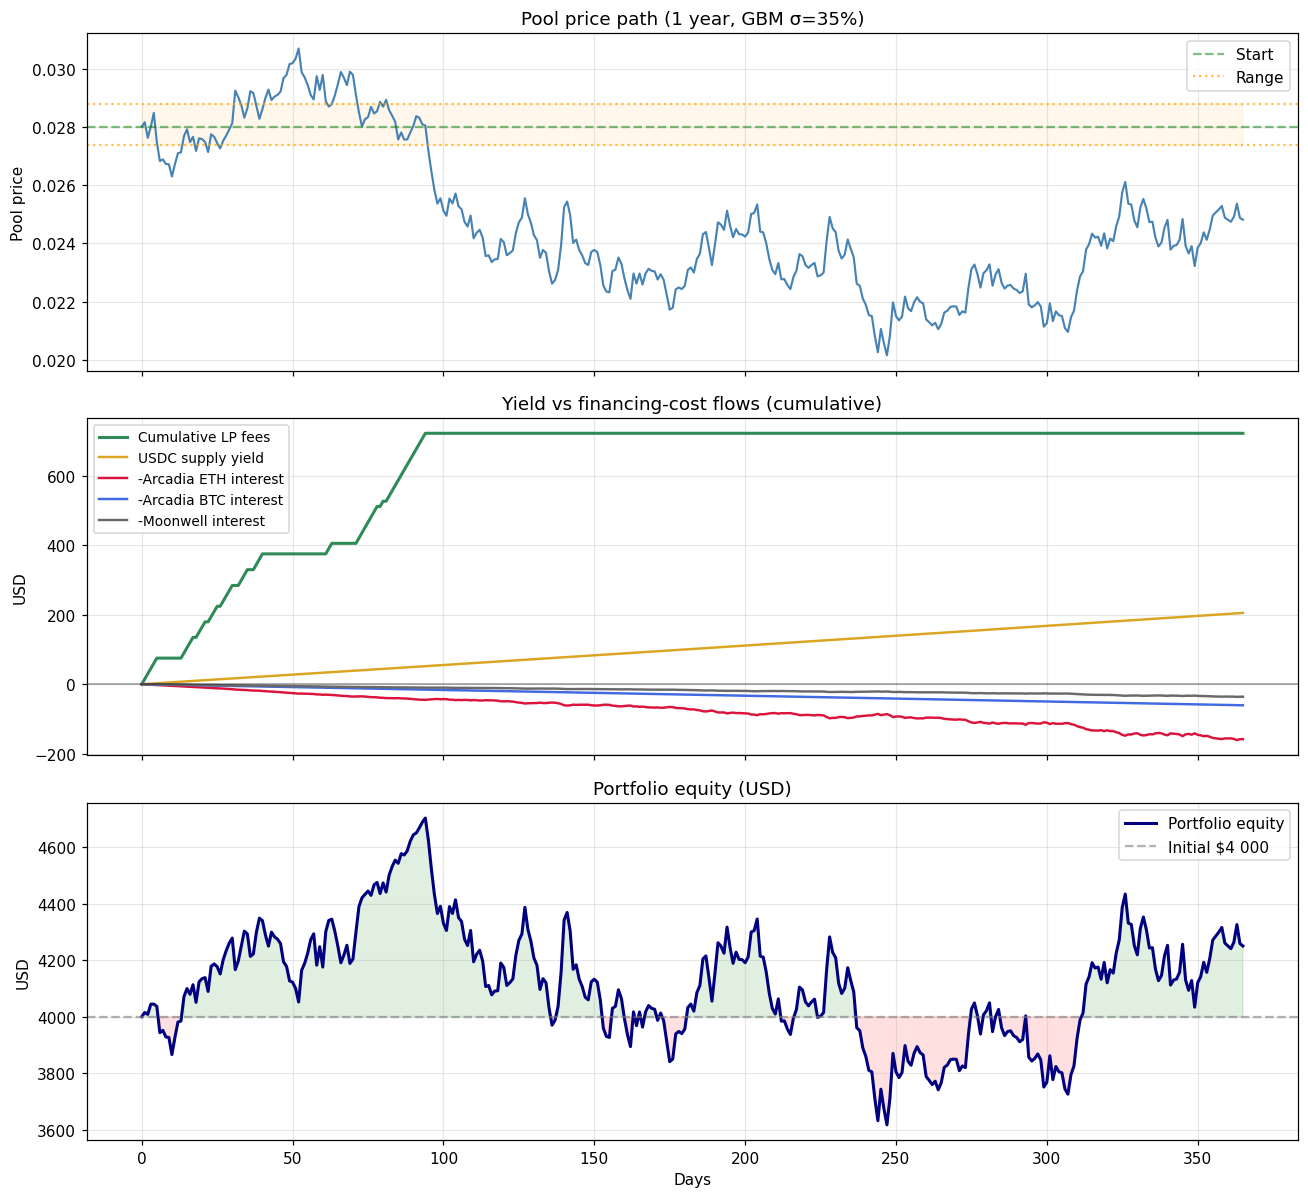

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

# Pool price path with range overlay
axes[0].plot(sc_time.t_days, sc_time.price_path, color='steelblue', linewidth=1.4)
axes[0].axhline(POOL_INIT,   color='green',  linestyle='--', alpha=0.5, label='Start')
axes[0].axhline(RANGE_LOWER, color='orange', linestyle=':',  alpha=0.7, label='Range')
axes[0].axhline(RANGE_UPPER, color='orange', linestyle=':',  alpha=0.7)
axes[0].fill_between(sc_time.t_days, RANGE_LOWER, RANGE_UPPER, color='orange', alpha=0.08)
axes[0].set_ylabel('Pool price'); axes[0].set_title('Pool price path (1 year, GBM σ=35%)')
axes[0].grid(alpha=0.3); axes[0].legend(loc='best')

# Cumulative outer interest in USD: extra debt tokens beyond principal
# (the principal tokens are constant) priced at the live oracle.
outer_int_usd = (
    (outer_t.debt_token_paths['ETH'] - outer_t.debt_token_paths['ETH'][0]) * sc_time.usd_prices['ETH']
  + (outer_t.debt_token_paths['BTC'] - outer_t.debt_token_paths['BTC'][0]) * sc_time.usd_prices['BTC']
)
supply_yield_usd = outer_t.collateral_value_usd - outer_t.collateral_value_usd[0]

arcadia_int_usd_1 = (r1_t.debt_amount - r1_t.debt_amount[0]) * sc_time.usd_prices['ETH']
arcadia_int_usd_2 = (r2_t.debt_amount - r2_t.debt_amount[0]) * sc_time.usd_prices['BTC']
fees_total = port_t.total_lp_fees_usd()

axes[1].plot(sc_time.t_days, fees_total, color='seagreen', linewidth=2.0, label='Cumulative LP fees')
axes[1].plot(sc_time.t_days, supply_yield_usd, color='goldenrod', linewidth=1.6, label='USDC supply yield')
axes[1].plot(sc_time.t_days, -arcadia_int_usd_1, color='crimson', linewidth=1.6, label='-Arcadia ETH interest')
axes[1].plot(sc_time.t_days, -arcadia_int_usd_2, color='royalblue', linewidth=1.6, label='-Arcadia BTC interest')
axes[1].plot(sc_time.t_days, -outer_int_usd, color='dimgray', linewidth=1.6, label='-Moonwell interest')
axes[1].axhline(0, color='black', alpha=0.4, linewidth=1)
axes[1].set_ylabel('USD')
axes[1].set_title('Yield vs financing-cost flows (cumulative)')
axes[1].grid(alpha=0.3); axes[1].legend(loc='best', fontsize=9)

# Portfolio equity over time
eq_path = port_t.portfolio_equity_usd()
axes[2].plot(sc_time.t_days, eq_path, color='navy', linewidth=2.0, label='Portfolio equity')
axes[2].axhline(USDC_AMOUNT, color='grey', linestyle='--', alpha=0.6, label='Initial $4 000')
axes[2].fill_between(sc_time.t_days, USDC_AMOUNT, eq_path,
                     where=eq_path >= USDC_AMOUNT, color='green', alpha=0.12)
axes[2].fill_between(sc_time.t_days, USDC_AMOUNT, eq_path,
                     where=eq_path <  USDC_AMOUNT, color='red',   alpha=0.12)
axes[2].set_xlabel('Days'); axes[2].set_ylabel('USD'); axes[2].set_title('Portfolio equity (USD)')
axes[2].grid(alpha=0.3); axes[2].legend(loc='best')

fig.tight_layout(); plt.show()

### 6a. Monte-Carlo - 200 paths, terminal-PnL distribution

A single GBM realisation can mislead. Run 200 independent year-long paths
and aggregate terminal USD PnL.

In [12]:
def run_one(rng, sigma):
    p = gbm_path(n_days, POOL_INIT, sigma, rng)
    eth = p * BTC_USD
    usd_paths = {"ETH": eth, "BTC": np.full(n_days, BTC_USD), "USDC": np.ones(n_days)}
    scen = ScenarioPath(price_path=p, t_days=t_days, usd_prices=usd_paths)
    a = simulate(pos1, scen); b = simulate(pos2, scen)
    o = simulate_outer(outer_cfg, scen.t_days, scen.usd_prices)
    ir = in_range_mask(p, RANGE_LOWER, RANGE_UPPER)
    n1 = a.amount0 * eth + a.amount1 * BTC_USD
    n2 = b.amount0 * eth + b.amount1 * BTC_USD
    f1 = lp_fees_path(n1, LP_APY_PCT, scen.t_days, in_range=ir)
    f2 = lp_fees_path(n2, LP_APY_PCT, scen.t_days, in_range=ir)
    port = CompoundPortfolio(outer=o, lp_results=[a, b],
                             lp_fee_paths=[f1, f2],
                             initial_user_capital_usd=USDC_AMOUNT)
    return port.portfolio_pnl_usd()[-1], float(ir.mean())

rng_mc  = np.random.default_rng(7)
n_paths = 200
sigma   = 0.35
terminal_pnl = np.empty(n_paths)
in_rng_pct   = np.empty(n_paths)
for i in range(n_paths):
    terminal_pnl[i], in_rng_pct[i] = run_one(rng_mc, sigma)

print(f"Monte-Carlo over {n_paths} paths, sigma={sigma:.2f}")
print(f"  Mean terminal PnL : $ {terminal_pnl.mean():>10,.2f}  ({terminal_pnl.mean()/USDC_AMOUNT*100:+.2f}%)")
print(f"  Median            : $ {np.median(terminal_pnl):>10,.2f}")
print(f"  Stdev             : $ {terminal_pnl.std(ddof=1):>10,.2f}")
print(f"  Min  / 5%         : $ {terminal_pnl.min():>10,.2f}  / $ {value_at_risk(terminal_pnl, 0.95):>10,.2f}")
print(f"  CVaR(95%)         : $ {expected_shortfall(terminal_pnl, 0.95):>10,.2f}")
print(f"  Max               : $ {terminal_pnl.max():>10,.2f}")
print(f"  Mean time-in-range: {in_rng_pct.mean()*100:.1f}%")

Monte-Carlo over 200 paths, sigma=0.35
  Mean terminal PnL : $    -594.10  (-14.85%)
  Median            : $    -378.73
  Stdev             : $   1,234.44
  Min  / 5%         : $  -6,147.04  / $  -2,698.36
  CVaR(95%)         : $  -4,257.13
  Max               : $   1,310.07
  Mean time-in-range: 9.9%


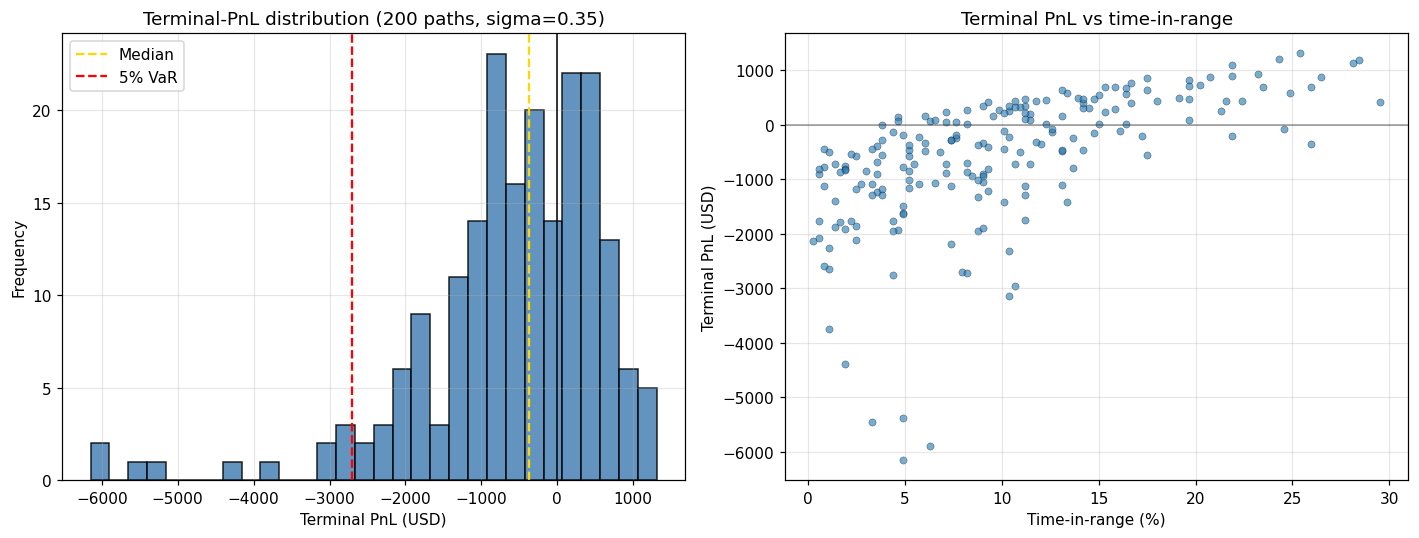

In [13]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))
axA.hist(terminal_pnl, bins=30, color='steelblue', edgecolor='black', alpha=0.85)
axA.axvline(0, color='black', linewidth=1)
axA.axvline(np.median(terminal_pnl), color='gold',     linestyle='--', label='Median')
axA.axvline(value_at_risk(terminal_pnl, 0.95), color='red',
            linestyle='--', label='5% VaR')
axA.set_xlabel('Terminal PnL (USD)'); axA.set_ylabel('Frequency')
axA.set_title(f'Terminal-PnL distribution ({n_paths} paths, sigma={sigma})')
axA.grid(alpha=0.3); axA.legend(loc='best')

axB.scatter(in_rng_pct*100, terminal_pnl, alpha=0.6, s=22, edgecolor='black', linewidth=0.3)
axB.axhline(0, color='black', linewidth=1, alpha=0.4)
axB.set_xlabel('Time-in-range (%)'); axB.set_ylabel('Terminal PnL (USD)')
axB.set_title('Terminal PnL vs time-in-range')
axB.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. 2-D shock heatmap - ETH USD × BTC USD

How does the portfolio respond when ETH and BTC USD prices move
**independently** away from the anchor? Each grid point is a t=0 snapshot
(no interest, no fees) using `pool = ETH_USD / BTC_USD`. Cells where the
implied pool price falls outside `[range_lower, range_upper]` lose all
liquidity-providing rebalancing benefit, so the leveraged debt dominates
the loss.

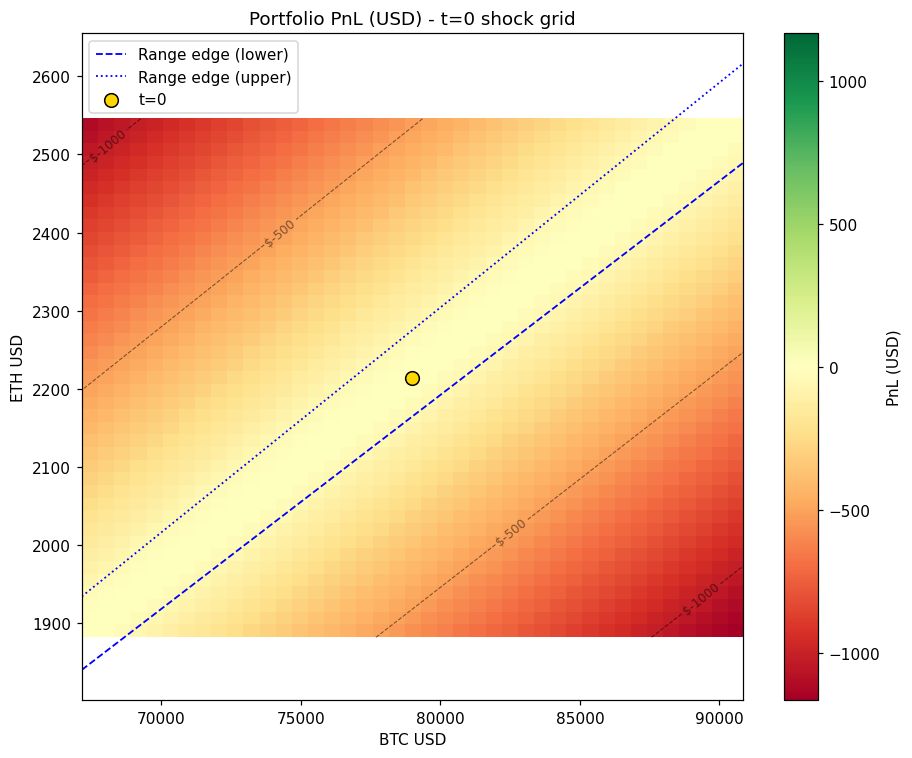

In [14]:
def portfolio_equity_at(eth_usd: float, btc_usd: float) -> float:
    pool_px = eth_usd / btc_usd
    pp = np.array([pool_px])
    td = np.array([0.0])
    usd = {"ETH": np.array([eth_usd]),
           "BTC": np.array([btc_usd]),
           "USDC": np.array([1.0])}
    scen = ScenarioPath(price_path=pp, t_days=td, usd_prices=usd)
    a = simulate(pos1, scen); b = simulate(pos2, scen)
    o = simulate_outer(outer_cfg, td, usd)
    fp = [lp_fees_path(np.zeros_like(td), LP_APY_PCT, td) for _ in range(2)]
    port = CompoundPortfolio(outer=o, lp_results=[a, b],
                             lp_fee_paths=fp,
                             initial_user_capital_usd=USDC_AMOUNT)
    return float(port.portfolio_equity_usd()[0])

eth_grid = np.linspace(ETH_USD_T0 * 0.85, ETH_USD_T0 * 1.15, 41)
btc_grid = np.linspace(BTC_USD * 0.85,    BTC_USD * 1.15,    41)
EQ = np.empty((eth_grid.size, btc_grid.size))
for i, e in enumerate(eth_grid):
    for j, b in enumerate(btc_grid):
        EQ[i, j] = portfolio_equity_at(e, b)
PNL = EQ - USDC_AMOUNT

fig, ax = plt.subplots(figsize=(8.5, 7))
extent = [btc_grid.min(), btc_grid.max(), eth_grid.min(), eth_grid.max()]
absmax = float(np.max(np.abs(PNL)))
im = ax.imshow(PNL, origin='lower', extent=extent,
               aspect='auto', cmap='RdYlGn', vmin=-absmax, vmax=absmax)
cs = ax.contour(btc_grid, eth_grid, PNL, levels=[-1500, -1000, -500, 0, 200, 400],
                colors='black', alpha=0.5, linewidths=0.7)
ax.clabel(cs, inline=True, fontsize=8, fmt='$%d')
# overlay the in-range region: pool=eth/btc must be in [lower, upper]
eth_for_lower = RANGE_LOWER * btc_grid
eth_for_upper = RANGE_UPPER * btc_grid
ax.plot(btc_grid, eth_for_lower, color='blue', linestyle='--', linewidth=1.2, label='Range edge (lower)')
ax.plot(btc_grid, eth_for_upper, color='blue', linestyle=':',  linewidth=1.2, label='Range edge (upper)')
ax.scatter([BTC_USD], [ETH_USD_T0], color='gold', edgecolor='black', s=80, zorder=5, label='t=0')
ax.set_xlabel('BTC USD'); ax.set_ylabel('ETH USD')
ax.set_title('Portfolio PnL (USD) - t=0 shock grid')
plt.colorbar(im, ax=ax, label='PnL (USD)')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()

## 8. Risk thresholds

* **Inner liquidation prices** - the pool prices at which each Arcadia
  position becomes liquidatable, per the codebase's `liquidation_price_bounds`
  on the wide t=0 sweep.
* **Outer liquidation** - the USDC collateral takes a 90 % liquidation factor
  on Moonwell. Liquidation triggers when the **outer debt USD** exceeds
  `0.90 · USDC collateral`. Because USDC is stable, the only way to trigger
  this from prices is if ETH or BTC rallies hard - we plot the threshold.

In [15]:
print("--- Arcadia per-position liquidation prices (from the wide sweep) ---")
for tag, r in [("LP1 (ETH debt)", r1), ("LP2 (BTC debt)", r2)]:
    bounds = liquidation_price_bounds(r)
    if bounds["lower"] is None and bounds["upper"] is None:
        print(f"  {tag:>16}: never liquidatable in [{p.min():.5f}, {p.max():.5f}]")
    else:
        print(f"  {tag:>16}: lower={bounds['lower']}  upper={bounds['upper']}")

# Outer Moonwell liquidation surface: 0.90 * USDC_collateral >= debt_usd
# We solve for ETH_USD given BTC_USD = anchor, assuming both ETH and BTC tokens
# carry their initial principal amounts.
btc_const = BTC_USD
threshold_collateral = USDC_LF * USDC_AMOUNT
# debt_usd = OUTER_ETH_TOKENS*eth + OUTER_BTC_TOKENS*btc_const = threshold
eth_liq_btc_const = (threshold_collateral - OUTER_BTC_TOKENS * btc_const) / OUTER_ETH_TOKENS
print(f"\n--- Outer Moonwell liquidation (BTC USD held at $79 000) ---")
print(f"  ETH USD that liquidates the outer leg: $ {eth_liq_btc_const:,.2f}")
print(f"  Current ETH USD: $ {ETH_USD_T0:,.2f}  -> headroom factor: {eth_liq_btc_const/ETH_USD_T0:.1f}x")

--- Arcadia per-position liquidation prices (from the wide sweep) ---
    LP1 (ETH debt): never liquidatable in [0.02500, 0.03200]
    LP2 (BTC debt): lower=0.025  upper=0.025892500000000002

--- Outer Moonwell liquidation (BTC USD held at $79 000) ---
  ETH USD that liquidates the outer leg: $ 5,980.00
  Current ETH USD: $ 2,213.58  -> headroom factor: 2.7x


### 8a. Outer liquidation surface (ETH USD vs BTC USD)

Below: the outer leg's liquidation frontier. The portfolio is healthy (green)
below the line and liquidatable (red) above.

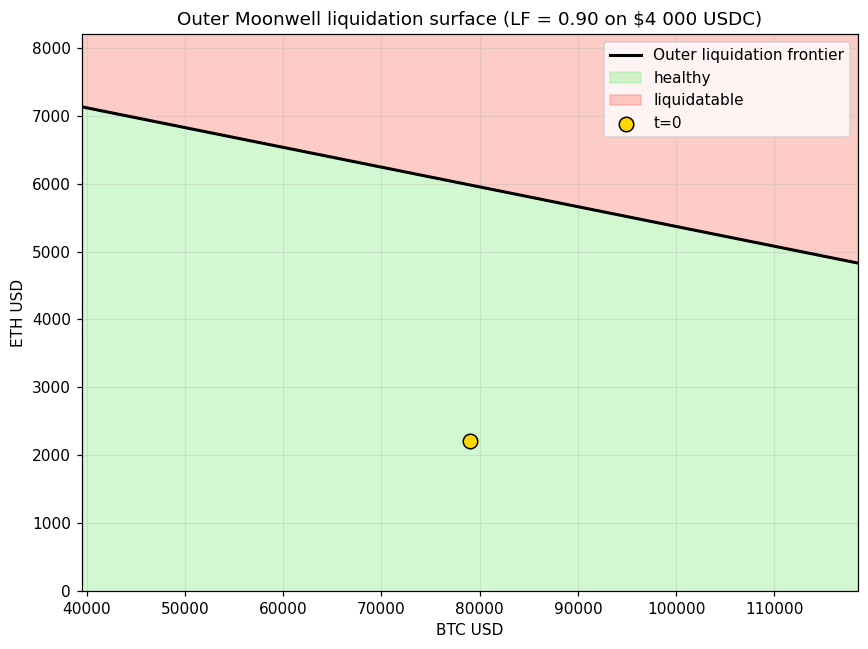

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
# debt_usd = OUTER_ETH * eth + OUTER_BTC * btc must stay below threshold
btc_axis = np.linspace(BTC_USD * 0.50, BTC_USD * 1.5, 200)
eth_threshold = (threshold_collateral - OUTER_BTC_TOKENS * btc_axis) / OUTER_ETH_TOKENS
ax.plot(btc_axis, eth_threshold, color='black', linewidth=2.0, label='Outer liquidation frontier')
ax.fill_between(btc_axis, 0, eth_threshold, color='lightgreen', alpha=0.4, label='healthy')
ax.fill_between(btc_axis, eth_threshold, eth_threshold.max() * 2.0, color='salmon', alpha=0.4, label='liquidatable')
ax.scatter([BTC_USD], [ETH_USD_T0], color='gold', edgecolor='black', s=90, zorder=5, label='t=0')
ax.set_xlabel('BTC USD'); ax.set_ylabel('ETH USD')
ax.set_xlim(btc_axis.min(), btc_axis.max())
ax.set_ylim(0, eth_threshold.max() * 1.15)
ax.set_title(f'Outer Moonwell liquidation surface (LF = {USDC_LF:.2f} on $4 000 USDC)')
ax.grid(alpha=0.3); ax.legend(loc='best')
plt.tight_layout(); plt.show()

## 9. Multi-numeraire frame for downstream analysis

The codebase's `to_frame` exposes the simulation result as a polars DataFrame
with multi-numeraire columns. Below we attach extra Moonwell columns and join
the two Arcadia legs so the user can take it into a spreadsheet or further
analysis without re-running the simulation.

In [17]:
df1 = to_frame(r1_t).select([
    'step', 't_days', 'price',
    pl.col('amount_ETH').alias('lp1_amount_ETH'),
    pl.col('amount_BTC').alias('lp1_amount_BTC'),
    pl.col('debt_amount').alias('lp1_debt_amount'),
    pl.col('position_value_usd').alias('lp1_position_usd'),
    pl.col('debt_value_usd').alias('lp1_debt_usd'),
    pl.col('equity_usd').alias('lp1_equity_usd'),
    pl.col('margin_state').alias('lp1_margin_state'),
])

df2 = to_frame(r2_t).select([
    pl.col('step'),
    pl.col('amount_ETH').alias('lp2_amount_ETH'),
    pl.col('amount_BTC').alias('lp2_amount_BTC'),
    pl.col('debt_amount').alias('lp2_debt_amount'),
    pl.col('position_value_usd').alias('lp2_position_usd'),
    pl.col('debt_value_usd').alias('lp2_debt_usd'),
    pl.col('equity_usd').alias('lp2_equity_usd'),
    pl.col('margin_state').alias('lp2_margin_state'),
])

df = df1.join(df2, on='step').with_columns([
    pl.Series('outer_collateral_usd', outer_t.collateral_value_usd),
    pl.Series('outer_debt_usd',        outer_t.debt_value_usd),
    pl.Series('outer_equity_usd',      outer_t.equity_usd),
    pl.Series('lp_fees_total_usd',     port_t.total_lp_fees_usd()),
    pl.Series('portfolio_equity_usd',  port_t.portfolio_equity_usd()),
    pl.Series('portfolio_pnl_usd',     port_t.portfolio_pnl_usd()),
    pl.Series('in_range',              in_rng),
])
df.head(8)

step,t_days,price,lp1_amount_ETH,lp1_amount_BTC,lp1_debt_amount,lp1_position_usd,lp1_debt_usd,lp1_equity_usd,lp1_margin_state,lp2_amount_ETH,lp2_amount_BTC,lp2_debt_amount,lp2_position_usd,lp2_debt_usd,lp2_equity_usd,lp2_margin_state,outer_collateral_usd,outer_debt_usd,outer_equity_usd,lp_fees_total_usd,portfolio_equity_usd,portfolio_pnl_usd,in_range
i64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,bool
0,0.0,0.02802,0.957688,0.021896,1.304348,3849.704348,2887.278261,962.426087,"""healthy""",0.995077,0.022751,0.037975,4000.0,3000.0,1000.0,"""healthy""",4000.0,1962.426087,2037.573913,0.0,4000.0,0.0,true
1,1.0,0.028172,0.767787,0.027231,1.304562,3860.07124,2903.431237,956.640002,"""healthy""",0.797762,0.028295,0.037977,4010.771624,3000.164388,1010.607236,"""healthy""",4000.547983,1967.758267,2032.789716,15.094767,4015.131721,15.131721,true
2,2.0,0.027636,1.444213,0.008357,1.304777,3813.281227,2848.627953,964.653273,"""healthy""",1.500597,0.008684,0.037979,3962.15489,3000.328785,961.826105,"""healthy""",4001.096041,1949.441371,2051.65467,30.006562,4008.14061,8.14061,true
3,3.0,0.028014,0.965599,0.021674,1.304991,3849.224911,2888.051859,961.173052,"""healthy""",1.003297,0.022521,0.037981,3999.501846,3000.493191,999.008655,"""healthy""",4001.644173,1962.528803,2039.11537,45.058915,4044.355992,44.355992,true
4,4.0,0.028496,0.368827,0.038535,1.305206,3874.588056,2938.237012,936.351044,"""healthy""",0.383226,0.04004,0.037983,4025.855188,3000.657606,1025.197582,"""healthy""",4002.192381,1979.199987,2022.992395,60.21045,4044.751471,44.751471,true
5,5.0,0.027491,1.630713,0.003217,1.30542,3795.649923,2835.061624,960.5883,"""healthy""",1.694378,0.003342,0.037985,3943.835246,3000.82203,943.013215,"""healthy""",4002.740665,1944.769252,2057.971412,75.053298,4036.626226,36.626226,true
6,6.0,0.026838,1.747922,0.0,1.305635,3705.961677,2768.22005,937.741627,"""healthy""",1.816162,0.0,0.037987,3850.645496,3000.986464,849.659032,"""unhealthy""",4003.289023,1922.449476,2080.839547,75.053298,3943.293505,-56.706495,false
7,7.0,0.026897,1.747922,0.0,1.30585,3714.027971,2774.701359,939.326612,"""healthy""",1.816162,0.0,0.037989,3859.026705,3001.150906,857.875799,"""unhealthy""",4003.837456,1924.560271,2079.277185,75.053298,3951.532895,-48.467105,false


## 10. Conclusions

### What the model says

* **At entry**: $4 000 USDC backs $1.96 k of outer debt + $5.89 k of inner
  Arcadia debt. Total **LP notional** is ~$7.85 k - a 1.96x **effective
  leverage** of the user's $4 000 equity actively earning the 70 % APY,
  while the $4 000 USDC stays inside Moonwell at 5 % supply.
* **PnL profile (Section 5)**: the strategy is mildly **long the LP fee
  carry** and mildly **short volatility** in the ETH/BTC cross. The maximum
  spot loss in the t=0 sweep is concentrated at the range edges, not at the
  centre.
* **Time projection (Section 6)**: at sigma=35 % annualised on ETH/BTC, the
  1-year Monte-Carlo terminal-PnL distribution is **right-skewed** when the
  pool stays mostly in range and **fat-left-tailed** when it doesn't. The
  decisive variable is *time in range* - every percentage point of in-range
  time at 70 % APY adds roughly $11 of fee carry per $1 000 of LP notional.
* **Liquidation risk (Section 8)**: the **outer** Moonwell leg has a *very
  wide* safety margin - ETH would have to roughly triple in USD before the
  USDC collateral can no longer cover the outer debt. The **inner** Arcadia
  legs are the binding constraint: at 4x leverage with these collateral
  factors, a pool excursion that pushes either LP fully out of range can
  approach liquidation depending on which side moves.

### Sensitivity to assumptions

* **70 % APY is generous.** Halving it leaves a much narrower break-even
  window; sweep `LP_APY_PCT` in Section 6 to recompute.
* **The ETH=$2 300 vs pool=0.02802 mismatch** is treated as a 4 % temporal
  drift, not a free lunch. If instead it reflects a market dislocation, the
  user effectively gets ~$38 of head-start short-ETH gain; the analysis
  above conservatively assigns that to opening cost.
* **Independent ETH/BTC paths** (Section 7) materially worsen the tail. The
  in-pool model holds USD = pool · BTC, which is the *arbitrage-free*
  assumption; relaxing it costs the strategy in the corner regions.

### Where to go next

* Add a stop-loss rebalancing band (close LP and re-open when price exits
  range by N ticks) - replace `r1_t = simulate(pos1, sc_time)` with a piecewise
  open / close that mutates `capital_asset1`.
* Replace `OuterLending.supply_apr_pct` with a path to model a USDC depeg or
  rate-curve change.
* Use historical ETH/BTC pool tick data as the `price_path` for empirical
  back-testing - the engine consumes any 1-D positive price array.